# Data Cleaning Exercise

Cleaning your data is crucial when starting a new data engineering project because it ensures the accuracy, consistency, and reliability of the dataset. Dirty data, which may include duplicates, missing values, and errors, can lead to incorrect analysis and insights, ultimately affecting the decision-making process. Data cleaning helps in identifying and rectifying these issues, providing a solid foundation for building effective data models and analytics. Additionally, clean data improves the performance of algorithms and enhances the overall efficiency of the project, leading to more trustworthy and actionable results.

Use Python, ```numpy```, ```pandas``` and/or ```matplotlib``` to analyse and clean your batch data:

## Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

Link to data source: https://data.europa.eu/data/datasets/30303037-3334-4032-312d-303030310000?locale=en

In [20]:
df = pd.read_csv('raw_beer_data.csv', sep=';', encoding='latin-1', skiprows=5)
df.head()

,Unnamed: 0,Absatz von Bier,Absatz von Biermischungen,Versteuerter Bierabsatz,Steuerfreier Bierabsatz,Steuerfreier Bierabsatz in EU-Länder,Steuerfreier Bierabsatz in Drittländer,Steuerfreier Bierabsatz als Haustrunk,Betriebene Braustätten,Verbrauch von Bier,Annähernder Verbrauch von Bier je Einwohner
0,NaN,hl,hl,hl,hl,hl,hl,hl,Anzahl,hl,l
1,1993,112141334,.,105207104,6934230,3847304,2711473,375452,1311,100785345,"130,3"
2,1994,115660265,.,107356274,8303991,4289903,3672039,342048,1299,108006115,"132,7"
3,1995,115252060,.,106345563,8906496,4696448,3882945,327102,1282,107091697,"131,1"
4,1996,112806908,.,103506368,9300540,5128537,3870892,301110,1276,104290568,"127,3"


## Understand the Data

View the first few rows, get summary statistics and check data types

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 11 columns):
 #   Column                                       Non-Null Count  Dtype
---  ------                                       --------------  -----
 0   Unnamed: 0                                   37 non-null     str  
 1   Absatz von Bier                              34 non-null     str  
 2   Absatz von Biermischungen                    34 non-null     str  
 3   Versteuerter Bierabsatz                      34 non-null     str  
 4   Steuerfreier Bierabsatz                      34 non-null     str  
 5   Steuerfreier Bierabsatz in EU-Länder         34 non-null     str  
 6   Steuerfreier Bierabsatz in Drittländer       34 non-null     str  
 7   Steuerfreier Bierabsatz als Haustrunk        34 non-null     str  
 8   Betriebene Braustätten                       34 non-null     str  
 9   Verbrauch von Bier                           34 non-null     str  
 10  Annähernder Verbrauch von Bier je Einwo

## Handle Missing Data

Identify missing values and fill or drop missing values

In [22]:
df = df.replace('.', np.nan)

print("Fehlende Werte pro Spalte vor der Bereinigung:")
print(df.isnull().sum())
print(f"\nGesamtanzahl fehlender Werte: {df.isnull().sum().sum()}")

Fehlende Werte pro Spalte vor der Bereinigung:
Unnamed: 0                                      1
Absatz von Bier                                 4
Absatz von Biermischungen                      10
Versteuerter Bierabsatz                         4
Steuerfreier Bierabsatz                         4
Steuerfreier Bierabsatz in EU-Länder            4
Steuerfreier Bierabsatz in Drittländer          4
Steuerfreier Bierabsatz als Haustrunk           4
Betriebene Braustätten                          4
Verbrauch von Bier                              4
Annähernder Verbrauch von Bier je Einwohner     4
dtype: int64

Gesamtanzahl fehlender Werte: 47


Die fehlenden Werte (markiert durch . in den Rohdaten) stammen aus einer Fußnotenzeile sowie vereinzelten Lücken in den numerischen Spalten. Da es sich um eine Zeitreihe handelt, werden Zeilen ohne gültiges Jahr später vollständig entfernt (siehe Abschnitt "Handle Incorrect Data Types"), da sie keine auswertbare Information liefern. Einzelne fehlende Werte in numerischen Spalten werden nicht durch geschätzte Werte ersetzt, sondern bleiben als fehlend markiert. Die fehlenden Werte in der Spalte Absatz_Biermisch_hl sind historisch bedingt: Biermischgetränke wurden in der Biersteuerstatistik erst ab 1999 separat erfasst, weshalb für die Jahre 1993–1998 keine Werte vorliegen.

## Handle Duplicates

Identify duplicates and remove them

In [23]:
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)

print(f"Zeilen vor Duplikatentfernung: {n_before}")
print(f"Zeilen nach Duplikatentfernung: {n_after}")
print(f"Entfernte Duplikate: {n_before - n_after}")

Zeilen vor Duplikatentfernung: 38
Zeilen nach Duplikatentfernung: 38
Entfernte Duplikate: 0


## Handle Incorrect Data Types

In [24]:
df.columns = ['Jahr', 'Absatz_Bier_hl', 'Absatz_Biermisch_hl', 'Versteuert_hl', 
              'Steuerfrei_hl', 'Export_EU_hl', 'Export_Drittland_hl', 
              'Haustrunk_hl', 'Braustaetten_Anzahl', 'Verbrauch_Bier_hl', 'Verbrauch_pro_Kopf_l']

df = df.drop(0, errors='ignore')

for col in df.columns:
    df[col] = df[col].astype(str).str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce')

rows_before = len(df)
df = df.dropna(subset=['Jahr'])
df['Jahr'] = df['Jahr'].astype(int)
print(f"Zeilen ohne gültiges Jahr entfernt: {rows_before - len(df)}")

df.info()

Zeilen ohne gültiges Jahr entfernt: 4
<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 1 to 33
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Jahr                  33 non-null     int64  
 1   Absatz_Bier_hl        33 non-null     float64
 2   Absatz_Biermisch_hl   27 non-null     float64
 3   Versteuert_hl         33 non-null     float64
 4   Steuerfrei_hl         33 non-null     float64
 5   Export_EU_hl          33 non-null     float64
 6   Export_Drittland_hl   33 non-null     float64
 7   Haustrunk_hl          33 non-null     float64
 8   Braustaetten_Anzahl   33 non-null     float64
 9   Verbrauch_Bier_hl     33 non-null     float64
 10  Verbrauch_pro_Kopf_l  33 non-null     float64
dtypes: float64(10), int64(1)
memory usage: 3.0 KB


## Handle Outliers

Identify outliers and remove or corret them

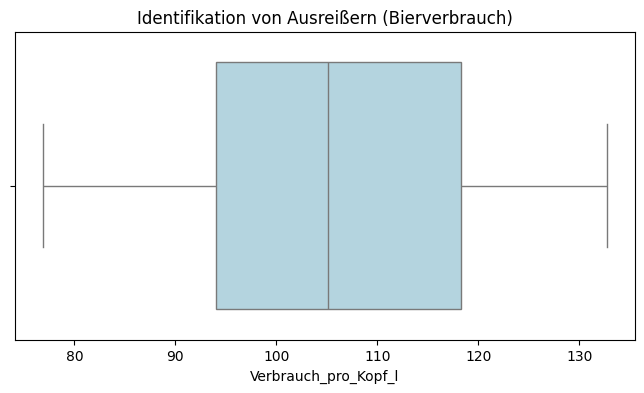

Gefundene Ausreißer:
Empty DataFrame
Columns: [Jahr, Absatz_Bier_hl, Absatz_Biermisch_hl, Versteuert_hl, Steuerfrei_hl, Export_EU_hl, Export_Drittland_hl, Haustrunk_hl, Braustaetten_Anzahl, Verbrauch_Bier_hl, Verbrauch_pro_Kopf_l]
Index: []


In [25]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Verbrauch_pro_Kopf_l'], color='lightblue')
plt.title('Identifikation von Ausreißern (Bierverbrauch)')
plt.show()

Q1 = df['Verbrauch_pro_Kopf_l'].quantile(0.25)
Q3 = df['Verbrauch_pro_Kopf_l'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Verbrauch_pro_Kopf_l'] < lower_bound) | (df['Verbrauch_pro_Kopf_l'] > upper_bound)]
print(f"Gefundene Ausreißer:\n{outliers}")

## Visualize Data

Use graphes, plots and/or diagrams to visualize the data

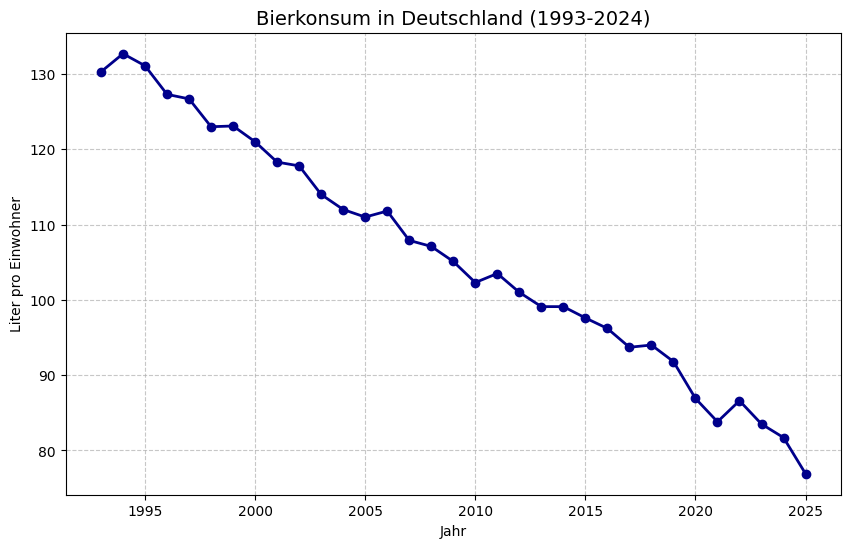

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(df['Jahr'], df['Verbrauch_pro_Kopf_l'], marker='o', color='darkblue', linewidth=2)

plt.title('Bierkonsum in Deutschland (1993-2024)', fontsize=14)
plt.xlabel('Jahr')
plt.ylabel('Liter pro Einwohner')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Save Cleaned Data

In [27]:
df.to_csv('cleaned_beer_data.csv', index=False)